In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
dataPath = Path(
    "../data/processed/"
    "penn_state_processed_combined_stats.csv"
)

reportsDir = Path("../reports")

reportsDir.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Data path:",
    dataPath.resolve()
)

Data path: /Users/sirahrahar/Desktop/penn-state-hockey-analytics/data/processed/penn_state_processed_combined_stats.csv


In [3]:
df = pd.read_csv(dataPath)

print(
    "Dataset shape:",
    df.shape
)

df.head()

Dataset shape: (68, 38)


,Date,Opponent,Location,Result,Box Score Link,WMT Game ID,PSU Goals,PSU Shots on Goal,PSU Total Shot Attempts,PSU Faceoffs Won,PSU Faceoffs Lost,PSU Faceoff %,PSU Penalty Minutes,PSU Blocks,PSU Saves,Opponent Goals,Opponent Shots on Goal,Opponent Total Shot Attempts,Opponent Faceoffs Won,Opponent Faceoffs Lost,Opponent Faceoff %,Opponent Penalty Minutes,Opponent Blocks,Opponent Saves,Win,Goal Differential,Shot Differential,Total Shots on Goal,Faceoff Differential,PSU Save %,Opponent Save %,Home Game,Venue_Type,Total Goals,Total Penalty Minutes,PSU Shooting %,Opponent Shooting %,Season
0,Friday Oct 3,Arizona State,"Tempe, Ariz. / Mullett Arena",W Win 6-3,https://gopsusports.com/boxscore/17959,6440318,6,47,69,32,45,41.56,18,16,35,3,38,65,45,32,58.44,16,13,41,1,3,9,85,-16.88,0.921,0.872,0,Away,9,34,12.765957,7.894737,2025-2026
1,Saturday Oct 4,Arizona State,"Tempe, Ariz. / Mullett Arena",W Win 4-2,https://gopsusports.com/boxscore/17960,6440319,4,46,76,29,42,40.85,14,13,45,2,47,69,42,29,59.15,8,17,42,1,2,-1,93,-18.30,0.957,0.913,0,Away,6,22,8.695652,4.255319,2025-2026
2,Thursday Oct 9,Clarkson,"University Park, Pa. / Pegula Ice Arena",L Loss 4-6,https://gopsusports.com/boxscore/17961,6440320,4,40,75,37,30,55.22,14,12,20,6,26,45,30,37,44.78,14,21,36,0,-2,14,66,10.44,0.769,0.900,1,Home,10,28,10.000000,23.076923,2025-2026
3,Friday Oct 10,Clarkson,"University Park, Pa. / Pegula Ice Arena",W Win 5-2,https://gopsusports.com/boxscore/17962,6440321,5,31,57,30,24,55.56,75,11,21,2,23,39,24,30,44.44,77,13,26,1,3,8,54,11.12,0.913,0.839,1,Home,7,152,16.129032,8.695652,2025-2026
4,Friday Oct 17,LIU,"University Park, Pa. / Pegula Ice Arena",W Win 5-4,https://gopsusports.com/boxscore/17963,6424375,5,41,66,37,33,52.86,10,15,32,4,36,63,33,37,47.14,25,11,36,1,1,5,77,5.72,0.889,0.878,1,Home,9,35,12.195122,11.111111,2025-2026


In [4]:
df = df.copy()

if "Win" in df.columns:
    df["Result Label"] = df["Win"].map(
        {
            1: "Win",
            0: "Loss",
        }
    )

if "Season" in df.columns:
    df["Season"] = df["Season"].astype(str)

print(
    "Games:",
    len(df)
)

print(
    "\nSeasons:"
)

if "Season" in df.columns:
    print(
        df["Season"].value_counts()
    )

Games: 68

Seasons:
Season
2025-2026    34
2024-2025    34
Name: count, dtype: int64


In [5]:
seasonMetrics = [
    "Win",
    "PSU Goals",
    "Opponent Goals",
    "Goal Differential",
    "PSU Shots on Goal",
    "Opponent Shots on Goal",
    "Shot Differential",
    "PSU Faceoff %",
    "Opponent Faceoff %",
    "Faceoff Differential",
    "PSU Shooting %",
    "Opponent Shooting %",
    "PSU Save %",
    "Opponent Save %",
    "PSU Blocks",
    "Opponent Blocks",
    "PSU Penalty Minutes",
    "Opponent Penalty Minutes",
]

availableSeasonMetrics = [
    column
    for column in seasonMetrics
    if column in df.columns
]

seasonSummary = (
    df.groupby("Season")[
        availableSeasonMetrics
    ]
    .mean()
    .reset_index()
)

if "Win" in seasonSummary.columns:
    seasonSummary["Win Percentage"] = (
        seasonSummary["Win"] * 100
    )

seasonSummary

,Season,Win,PSU Goals,Opponent Goals,Goal Differential,PSU Shots on Goal,Opponent Shots on Goal,Shot Differential,PSU Faceoff %,Opponent Faceoff %,Faceoff Differential,PSU Shooting %,Opponent Shooting %,PSU Save %,Opponent Save %,PSU Blocks,Opponent Blocks,PSU Penalty Minutes,Opponent Penalty Minutes,Win Percentage
0,2024-2025,0.588235,3.735294,3.029412,0.705882,35.088235,34.323529,0.764706,51.484706,48.515294,2.969412,10.549729,8.727417,0.912735,0.894588,12.441176,13.0,18.823529,20.294118,58.823529
1,2025-2026,0.588235,3.735294,3.029412,0.705882,35.088235,34.323529,0.764706,51.484706,48.515294,2.969412,10.549729,8.727417,0.912735,0.894588,12.441176,13.0,18.823529,20.294118,58.823529


In [6]:
seasonSummary.to_csv(
    reportsDir /
    "season_comparison.csv",

    index=False
)

print(
    "Saved season comparison."
)

Saved season comparison.


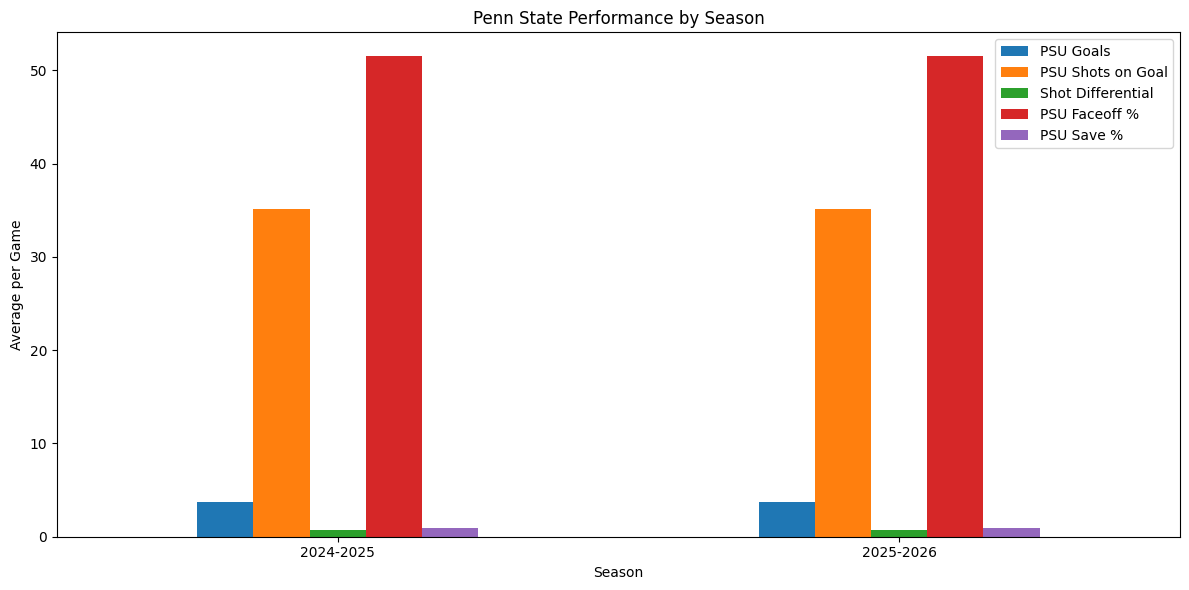

In [7]:
chartMetrics = [
    metric
    for metric in [
        "PSU Goals",
        "PSU Shots on Goal",
        "Shot Differential",
        "PSU Faceoff %",
        "PSU Save %",
    ]
    if metric in seasonSummary.columns
]

seasonChartData = (
    seasonSummary[
        ["Season"] + chartMetrics
    ]
    .set_index("Season")
)

seasonChartData.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Penn State Performance by Season"
)

plt.xlabel(
    "Season"
)

plt.ylabel(
    "Average per Game"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [8]:
if "Location" in df.columns:

    locationMetrics = [
        "Win",
        "PSU Goals",
        "Opponent Goals",
        "Goal Differential",
        "PSU Shots on Goal",
        "Opponent Shots on Goal",
        "Shot Differential",
        "PSU Faceoff %",
        "PSU Save %",
        "PSU Blocks",
        "PSU Penalty Minutes",
    ]

    availableLocationMetrics = [
        column
        for column in locationMetrics
        if column in df.columns
    ]

    locationSummary = (
        df.groupby("Location")[
            availableLocationMetrics
        ]
        .agg(
            [
                "mean",
                "count",
            ]
        )
    )

    locationSummary

In [9]:
if "Location" in df.columns:

    locationSummaryClean = (
        df.groupby("Location")
        .agg(
            Games=(
                "Win",
                "count",
            ),

            Wins=(
                "Win",
                "sum",
            ),

            Win_Percentage=(
                "Win",
                "mean",
            ),

            Avg_PSU_Goals=(
                "PSU Goals",
                "mean",
            ),

            Avg_Opponent_Goals=(
                "Opponent Goals",
                "mean",
            ),

            Avg_Goal_Differential=(
                "Goal Differential",
                "mean",
            ),

            Avg_Shot_Differential=(
                "Shot Differential",
                "mean",
            ),
        )
        .reset_index()
    )

    locationSummaryClean[
        "Win Percentage"
    ] = (
        locationSummaryClean[
            "Win_Percentage"
        ] * 100
    )

    locationSummaryClean

In [10]:
if "Location" in df.columns:

    locationSummaryClean.to_csv(
        reportsDir /
        "location_performance.csv",

        index=False
    )

    print(
        "Saved location performance."
    )

Saved location performance.


In [11]:
opponentSummary = (
    df.groupby("Opponent")
    .agg(
        Games=(
            "Win",
            "count",
        ),

        Wins=(
            "Win",
            "sum",
        ),

        Win_Percentage=(
            "Win",
            "mean",
        ),

        Avg_PSU_Goals=(
            "PSU Goals",
            "mean",
        ),

        Avg_Opponent_Goals=(
            "Opponent Goals",
            "mean",
        ),

        Avg_Goal_Differential=(
            "Goal Differential",
            "mean",
        ),

        Avg_Shot_Differential=(
            "Shot Differential",
            "mean",
        ),
    )
    .reset_index()
)

opponentSummary[
    "Win Percentage"
] = (
    opponentSummary[
        "Win_Percentage"
    ] * 100
)

opponentSummary = opponentSummary.sort_values(
    by=[
        "Games",
        "Win Percentage",
    ],

    ascending=[
        False,
        False,
    ]
)

opponentSummary

,Opponent,Games,Wins,Win_Percentage,Avg_PSU_Goals,Avg_Opponent_Goals,Avg_Goal_Differential,Avg_Shot_Differential,Win Percentage
5,Minnesota,10,8,0.800000,3.600000,1.600000,2.000000,7.600000,80.000000
7,Notre Dame,8,4,0.500000,4.000000,2.750000,1.250000,-1.500000,50.000000
11,Wisconsin,8,4,0.500000,3.750000,3.750000,0.000000,-9.250000,50.000000
4,Michigan State,8,0,0.000000,2.000000,4.500000,-2.500000,-6.000000,0.000000
8,Ohio State,6,6,1.000000,6.333333,3.333333,3.000000,-1.333333,100.000000
3,Michigan,6,2,0.333333,3.000000,4.333333,-1.333333,-4.000000,33.333333
0,Arizona State,4,4,1.000000,5.000000,2.500000,2.500000,4.000000,100.000000
2,LIU,4,4,1.000000,4.000000,2.000000,2.000000,7.500000,100.000000
10,Stonehill,4,4,1.000000,3.500000,2.000000,1.500000,4.000000,100.000000
1,Clarkson,4,2,0.500000,4.500000,4.000000,0.500000,11.000000,50.000000


In [12]:
toughestOpponents = (
    opponentSummary[
        opponentSummary["Games"] >= 2
    ]
    .sort_values(
        by=[
            "Win Percentage",
            "Avg_Goal_Differential",
        ],
        ascending=[
            True,
            True,
        ]
    )
)

toughestOpponents.head(10)

,Opponent,Games,Wins,Win_Percentage,Avg_PSU_Goals,Avg_Opponent_Goals,Avg_Goal_Differential,Avg_Shot_Differential,Win Percentage
4,Michigan State,8,0,0.000000,2.00,4.500000,-2.500000,-6.00,0.000000
6,Minnesota-Duluth,2,0,0.000000,1.00,3.000000,-2.000000,-9.00,0.000000
3,Michigan,6,2,0.333333,3.00,4.333333,-1.333333,-4.00,33.333333
11,Wisconsin,8,4,0.500000,3.75,3.750000,0.000000,-9.25,50.000000
1,Clarkson,4,2,0.500000,4.50,4.000000,0.500000,11.00,50.000000
7,Notre Dame,8,4,0.500000,4.00,2.750000,1.250000,-1.50,50.000000
9,RIT,4,2,0.500000,3.50,2.000000,1.500000,13.50,50.000000
5,Minnesota,10,8,0.800000,3.60,1.600000,2.000000,7.60,80.000000
10,Stonehill,4,4,1.000000,3.50,2.000000,1.500000,4.00,100.000000
2,LIU,4,4,1.000000,4.00,2.000000,2.000000,7.50,100.000000


In [13]:
bestMatchups = (
    opponentSummary[
        opponentSummary["Games"] >= 2
    ]
    .sort_values(
        by=[
            "Win Percentage",
            "Avg_Goal_Differential",
        ],
        ascending=[
            False,
            False,
        ]
    )
)

bestMatchups.head(10)

,Opponent,Games,Wins,Win_Percentage,Avg_PSU_Goals,Avg_Opponent_Goals,Avg_Goal_Differential,Avg_Shot_Differential,Win Percentage
8,Ohio State,6,6,1.000000,6.333333,3.333333,3.000000,-1.333333,100.000000
0,Arizona State,4,4,1.000000,5.000000,2.500000,2.500000,4.000000,100.000000
2,LIU,4,4,1.000000,4.000000,2.000000,2.000000,7.500000,100.000000
10,Stonehill,4,4,1.000000,3.500000,2.000000,1.500000,4.000000,100.000000
5,Minnesota,10,8,0.800000,3.600000,1.600000,2.000000,7.600000,80.000000
9,RIT,4,2,0.500000,3.500000,2.000000,1.500000,13.500000,50.000000
7,Notre Dame,8,4,0.500000,4.000000,2.750000,1.250000,-1.500000,50.000000
1,Clarkson,4,2,0.500000,4.500000,4.000000,0.500000,11.000000,50.000000
11,Wisconsin,8,4,0.500000,3.750000,3.750000,0.000000,-9.250000,50.000000
3,Michigan,6,2,0.333333,3.000000,4.333333,-1.333333,-4.000000,33.333333


In [14]:
opponentSummary.to_csv(
    reportsDir /
    "opponent_performance.csv",

    index=False
)

toughestOpponents.to_csv(
    reportsDir /
    "toughest_opponents.csv",

    index=False
)

bestMatchups.to_csv(
    reportsDir /
    "best_opponent_matchups.csv",

    index=False
)

print(
    "Saved opponent reports."
)

Saved opponent reports.


In [15]:
gameColumns = [
    column
    for column in [
        "Season",
        "Date",
        "Opponent",
        "Location",
        "Result",
        "PSU Goals",
        "Opponent Goals",
        "Goal Differential",
        "PSU Shots on Goal",
        "Opponent Shots on Goal",
        "Shot Differential",
        "PSU Shooting %",
        "PSU Save %",
    ]
    if column in df.columns
]

largestWin = (
    df.sort_values(
        "Goal Differential",
        ascending=False
    )
    .head(1)[gameColumns]
)

largestLoss = (
    df.sort_values(
        "Goal Differential",
        ascending=True
    )
    .head(1)[gameColumns]
)

highestScoringGame = (
    df.sort_values(
        "PSU Goals",
        ascending=False
    )
    .head(1)[gameColumns]
)

bestDefensiveGame = (
    df.sort_values(
        [
            "Opponent Goals",
            "Opponent Shots on Goal",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .head(1)[gameColumns]
)

print(
    "Largest Win"
)

display(
    largestWin
)

print(
    "Largest Loss"
)

display(
    largestLoss
)

print(
    "Highest Scoring Game"
)

display(
    highestScoringGame
)

print(
    "Best Defensive Game"
)

display(
    bestDefensiveGame
)

Largest Win


,Season,Date,Opponent,Location,Result,PSU Goals,Opponent Goals,Goal Differential,PSU Shots on Goal,Opponent Shots on Goal,Shot Differential,PSU Shooting %,PSU Save %
60,2024-2025,Friday Feb 20,Ohio State,"University Park, Pa. / Pegula Ice Arena",W Win 11-4,11,4,7,38,42,-4,28.947368,0.905


Largest Loss


,Season,Date,Opponent,Location,Result,PSU Goals,Opponent Goals,Goal Differential,PSU Shots on Goal,Opponent Shots on Goal,Shot Differential,PSU Shooting %,PSU Save %
45,2024-2025,Friday Nov 14,Michigan,"University Park, Pa. / Pegula Ice Arena",L Loss 1-7,1,7,-6,27,37,-10,3.703704,0.811


Highest Scoring Game


,Season,Date,Opponent,Location,Result,PSU Goals,Opponent Goals,Goal Differential,PSU Shots on Goal,Opponent Shots on Goal,Shot Differential,PSU Shooting %,PSU Save %
60,2024-2025,Friday Feb 20,Ohio State,"University Park, Pa. / Pegula Ice Arena",W Win 11-4,11,4,7,38,42,-4,28.947368,0.905


Best Defensive Game


,Season,Date,Opponent,Location,Result,PSU Goals,Opponent Goals,Goal Differential,PSU Shots on Goal,Opponent Shots on Goal,Shot Differential,PSU Shooting %,PSU Save %
5,2025-2026,Saturday Oct 18,LIU,"University Park, Pa. / Pegula Ice Arena",W Win 3-0,3,0,3,38,28,10,7.894737,1.0


In [16]:
notableGames = pd.concat(
    [
        largestWin.assign(
            Category="Largest Win"
        ),

        largestLoss.assign(
            Category="Largest Loss"
        ),

        highestScoringGame.assign(
            Category="Highest Scoring Game"
        ),

        bestDefensiveGame.assign(
            Category="Best Defensive Game"
        ),
    ],

    ignore_index=True
)

notableGames.to_csv(
    reportsDir /
    "notable_games.csv",

    index=False
)

notableGames

,Season,Date,Opponent,Location,Result,PSU Goals,Opponent Goals,Goal Differential,PSU Shots on Goal,Opponent Shots on Goal,Shot Differential,PSU Shooting %,PSU Save %,Category
0,2024-2025,Friday Feb 20,Ohio State,"University Park, Pa. / Pegula Ice Arena",W Win 11-4,11,4,7,38,42,-4,28.947368,0.905,Largest Win
1,2024-2025,Friday Nov 14,Michigan,"University Park, Pa. / Pegula Ice Arena",L Loss 1-7,1,7,-6,27,37,-10,3.703704,0.811,Largest Loss
2,2024-2025,Friday Feb 20,Ohio State,"University Park, Pa. / Pegula Ice Arena",W Win 11-4,11,4,7,38,42,-4,28.947368,0.905,Highest Scoring Game
3,2025-2026,Saturday Oct 18,LIU,"University Park, Pa. / Pegula Ice Arena",W Win 3-0,3,0,3,38,28,10,7.894737,1.000,Best Defensive Game


In [17]:
winningFormulaFeatures = [
    column
    for column in [
        "Shot Differential",
        "Faceoff Differential",
        "PSU Faceoff %",
        "PSU Blocks",
        "PSU Penalty Minutes",
        "PSU Shots on Goal",
    ]
    if column in df.columns
]

winningFormulaResults = []

In [18]:
for feature in winningFormulaFeatures:

    medianValue = df[feature].median()

    aboveMedian = df[
        df[feature] >= medianValue
    ]

    belowMedian = df[
        df[feature] < medianValue
    ]

    aboveWinRate = (
        aboveMedian["Win"].mean() * 100
        if len(aboveMedian) > 0
        else np.nan
    )

    belowWinRate = (
        belowMedian["Win"].mean() * 100
        if len(belowMedian) > 0
        else np.nan
    )

    winningFormulaResults.append(
        {
            "Feature": feature,

            "Median Threshold": medianValue,

            "Win % At or Above Threshold":
                aboveWinRate,

            "Win % Below Threshold":
                belowWinRate,

            "Win % Difference":
                aboveWinRate -
                belowWinRate,
        }
    )

winningFormulaDf = (
    pd.DataFrame(
        winningFormulaResults
    )
    .sort_values(
        "Win % Difference",
        ascending=False
    )
    .reset_index(drop=True)
)

winningFormulaDf

,Feature,Median Threshold,Win % At or Above Threshold,Win % Below Threshold,Win % Difference
0,Shot Differential,0.500,82.352941,35.294118,47.058824
1,Faceoff Differential,4.550,76.470588,41.176471,35.294118
2,PSU Faceoff %,52.275,76.470588,41.176471,35.294118
3,PSU Blocks,12.000,70.000000,42.857143,27.142857
4,PSU Shots on Goal,35.500,70.588235,47.058824,23.529412
5,PSU Penalty Minutes,14.000,63.157895,53.333333,9.824561


In [19]:
winningFormulaDf.to_csv(
    reportsDir /
    "winning_formula.csv",

    index=False
)

print(
    "Saved winning formula report."
)

Saved winning formula report.


In [20]:
print(
    "Highest-impact winning formula feature:"
)

display(
    winningFormulaDf.head(1)
)

if "Location" in df.columns:

    bestLocation = (
        locationSummaryClean
        .sort_values(
            "Win Percentage",
            ascending=False
        )
        .head(1)
    )

    print(
        "\nBest location:"
    )

    display(
        bestLocation
    )

print(
    "\nToughest opponent:"
)

display(
    toughestOpponents.head(1)
)

print(
    "\nBest opponent matchup:"
)

display(
    bestMatchups.head(1)
)

Highest-impact winning formula feature:


,Feature,Median Threshold,Win % At or Above Threshold,Win % Below Threshold,Win % Difference
0,Shot Differential,0.5,82.352941,35.294118,47.058824



Best location:


,Location,Games,Wins,Win_Percentage,Avg_PSU_Goals,Avg_Opponent_Goals,Avg_Goal_Differential,Avg_Shot_Differential,Win Percentage
2,"Columbus, Ohio / Value City Arena",2,2,1.0,3.0,2.0,1.0,7.0,100.0



Toughest opponent:


,Opponent,Games,Wins,Win_Percentage,Avg_PSU_Goals,Avg_Opponent_Goals,Avg_Goal_Differential,Avg_Shot_Differential,Win Percentage
4,Michigan State,8,0,0.0,2.0,4.5,-2.5,-6.0,0.0



Best opponent matchup:


,Opponent,Games,Wins,Win_Percentage,Avg_PSU_Goals,Avg_Opponent_Goals,Avg_Goal_Differential,Avg_Shot_Differential,Win Percentage
8,Ohio State,6,6,1.0,6.333333,3.333333,3.0,-1.333333,100.0
